# Import and Function Definition

In [4]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
import os, sys, pickle, glob
import qutip as qt
import textwrap
import experiments as meas

from copy import deepcopy
from collections import defaultdict
from tqdm.notebook import tqdm
from experiments.MM_dual_rail_base import MM_dual_rail_base
from fitting.fit_display_classes import GeneralFitting
from fitting.wigner import WignerAnalysis
from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner


REPO_ROOT = r"C:\python\multimode_expts" 
RUN_PREFIX = "JOB-20260414"  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Helper Functions & Definitions

Run this section once (after the import cell). All later sections only call these -- no section depends on another.

In [5]:
import numpy as np


def common_grid_jobs(headers):
    # Preserve every saved job in the manifest. Only the rectangular analysis
    # aggregate excludes orphan/short rows; raw preview can still show those jobs.
    grouped = {}
    for header in headers:
        cfg = header.cfg.expt
        initial = tuple(cfg.spectroscopy_occupations)
        final = tuple(cfg.get('offdiag_decoder_occupation', cfg.get('spectroscopy_final_occupations', initial)))
        grouped.setdefault((final, initial), []).append(header)
    valid, excluded = {}, []
    for pair, chunks in grouped.items():
        grids = {}
        for header in chunks:
            cfg = header.cfg.expt
            phases = (0., 90.) if 'offdiag_cycles' in cfg else (float(cfg.spectroscopy_analyzer_phase),)
            for phase in phases:
                grids.setdefault(phase, []).extend(cfg.get('offdiag_cycles', cfg.get('floquet_cycles', [])))
        first = tuple(sorted(grids.get(0., [])))
        second = tuple(sorted(grids.get(90., [])))
        regular = len(first) < 3 or len(set(np.diff(first))) == 1
        if not first or first != second or len(set(first)) != len(first) or first[0] != 0 or not regular:
            excluded.extend(dict(job_id=item.job_id, reason='orphan, duplicate, or unequal analyzer/cycle coverage') for item in chunks)
        else:
            valid[pair] = (first, chunks)
    if not valid:
        return [], excluded, []
    # Longest available contiguous grid starting at zero, selected without looking
    # at amplitudes, fitted peaks, or theory. Do not silently trim long rows.
    grid = max((value[0] for value in valid.values()), key=len)
    kept = []
    for row_grid, chunks in valid.values():
        if row_grid == grid:
            kept.extend(item.job_id for item in chunks)
        else:
            excluded.extend(dict(job_id=item.job_id, reason='short row: differs from longest saved cycle grid') for item in chunks)
    return sorted(kept), excluded, list(grid)


# Saved HDF5 data: one self-contained data cell per spectrum

Run the **Helper Functions & Definitions**, **path settings**, and **HDF5 helpers** cells once. Every data cell
below shows its own calibration and spectroscopy job IDs or ranges at the top.
That same cell loads its local Floquet station settings when available, reads
only those HDF5 jobs, and calls `analyze()` and `display()`. Run any one data
cell independently of the other data cells. The shared helpers do not select
or load any job, station, or dataset-wide hardware.

T/g comes from saved HDF5 hardware or the verified acquisition Floquet CSV.
If neither is available, the cell stops before plotting a frequency axis or theory.
The HDF5 experiment data come directly from local files. No instrument server
is contacted, and nothing is exported.


In [7]:
# Shared path only. Every data cell below declares and loads its own hardware.
BASE_DIR = r"C:\experiments"  # PROJECT/data/JOB-....h5


In [72]:
# HDF5 analysis/display helpers; no JobClient, pickle, or output files.
import json
import math
from collections import Counter
from pathlib import Path
from types import SimpleNamespace
from time import perf_counter

import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display as notebook_display
from slab import AttrDict
from experiments.qsim.floquet_dark_mode_readout import EncodingHamiltonianSpectroscopyExperiment

if "common_grid_jobs" not in globals():
    raise RuntimeError("Run the Helper Functions & Definitions cell first")
if "BASE_DIR" not in globals():
    raise RuntimeError("Run the path settings cell first")

# HDF5 reconstruction definitions used by this notebook.
def make_plain(value):
    if hasattr(value, 'tolist'):
        value = value.tolist()
    if isinstance(value, dict):
        return {str(key): make_plain(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [make_plain(item) for item in value]
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


def parameter_key(value):
    return json.dumps(make_plain(value), sort_keys=True, allow_nan=False)


def saved_parameters(expt):
    # These parameters really are in H5. Pulse-CSV values and RFSoC clocks
    # were NOT included in older H5 files, and cannot be inferred from job names.
    ecfg = expt.cfg.expt
    modes = list(map(int, ecfg.swap_stors))
    man = int(ecfg.get('man_mode_no', 1))
    kerr = np.asarray(expt.cfg.device.manipulate.kerr).reshape(-1)
    return dict(photon_number=sum(ecfg.spectroscopy_occupations), 
                swap_stors=modes,
                physical_kerr_MHz=-abs(float(kerr[min(man - 1, len(kerr) - 1)])),
                man_mode_no=man, 
                floquet_waveform=ecfg.get('floquet_waveform'),
                scramble_sync_cycles=int(ecfg.get('scramble_sync_cycles', 10)),
                floquet_gauss_sigma=ecfg.get('floquet_gauss_sigma'),
                use_multiphoton_swap=bool(ecfg.get('use_multiphoton_swap', False)))


class SavedSpectroscopyExperiment(EncodingHamiltonianSpectroscopyExperiment):
    """Notebook-only analysis adapter; H5 objects never initialize instruments."""

    @classmethod
    def _saved_parameters(cls, expts, station=None):
        first = expts[0]
        parameters = saved_parameters(first)
        metadata = getattr(first, 'saved_hardware', None)
        if not metadata or metadata.get('floquet_cycle_us') is None or metadata.get('couplings_MHz') is None:
            raise ValueError('This H5 has no archived cycle clock/couplings. Supply their historical values '
                             'in the dataset hardware settings; raw cycle-domain data are already loaded.')
        cycle_us = float(metadata['floquet_cycle_us'])
        coupling = np.asarray(metadata['couplings_MHz'], dtype=float)
        modes = parameters['swap_stors']
        if (cycle_us <= 0 or not np.isfinite(cycle_us) or coupling.shape != (len(modes),)
                or not np.isfinite(coupling).all() or np.any(coupling <= 0)):
            raise ValueError('Archived cycle time/couplings do not match the selected modes')
        detuning = cls._saved_detunings(first.cfg.expt, len(modes))
        for child in expts[1:]:
            if saved_parameters(child) != parameters:
                raise ValueError('Selected H5 jobs have different physical settings')
            if not np.array_equal(cls._saved_detunings(child.cfg.expt, len(modes)), detuning):
                raise ValueError('Selected H5 jobs have different disorder detunings')
            other = getattr(child, 'saved_hardware', None)
            if (not other or other.get('floquet_cycle_us') != cycle_us
                    or not np.array_equal(other.get('couplings_MHz'), coupling)):
                raise ValueError('Selected H5 jobs have different archived clocks/couplings')
        hardware = AttrDict(dict(floquet_cycle_us=cycle_us, couplings_MHz=coupling,
                                physical_kerr_MHz=parameters['physical_kerr_MHz'],
                                decoder_cycle_us=float(metadata.get('decoder_cycle_us', cycle_us)),
                                detunings_MHz=detuning.copy(), source=metadata['source']))
        return AttrDict(dict(swap_stors=modes, detunings=detuning,
                             mode_labels=['M1'] + [f'S{mode}' for mode in modes], hardware=hardware))


    @classmethod
    def _postprocess_reconstruction(cls, 
                                    reconstruction, 
                                    saved_correction, 
                                    calibration,
                                    hardware, 
                                    phase_frame,
                                    manual_kerr_MHz, 
                                    cycle_branches,
                                    legacy):
        
        result = super()._postprocess_reconstruction(reconstruction, 
                                                     saved_correction, 
                                                     calibration, 
                                                     hardware,
                                                     phase_frame, 
                                                     manual_kerr_MHz, 
                                                     cycle_branches, 
                                                     legacy)
        
        actual_us = float(hardware.floquet_cycle_us)
        decoder_us = float(hardware.get('decoder_cycle_us', actual_us))
        
        if np.isclose(decoder_us, actual_us, rtol=1e-9, atol=1e-12):
            return result
        if result.phase_frame != 'as_acquired':
            raise ValueError('Different archived decoder/physical clocks are validated here only for '
                             "phase_frame='as_acquired', manual_kerr_MHz=None")
        if saved_correction.application_sign != -1 or saved_correction.modes != {'final_analyzer'}:
            raise ValueError('The archived decoder-clock correction requires the recorded -1 final-analyzer convention')

        # DDS detuning acts for actual_us; the decoder advanced its reference phase
        # for decoder_us. Remove only their known difference, independently of peaks/H.
        corrected = result.reconstruction  # base method already copied the raw A.
        final = np.asarray(corrected.final_occupations)
        detunings = np.asarray(hardware.detunings_MHz)
        n_man = final[:, 0]
        reference_kerr = float(hardware.physical_kerr_MHz) * n_man * (n_man - 1) / 2
        # The saved gamma also included K*choose(n_M1,2)*T_decoder.
        # Use the same independently saved K, not a value fitted to peaks.
        turns_per_cycle = (decoder_us - actual_us) * (final[:, 1:] @ detunings - reference_kerr)
        rotation = np.exp(-2j * np.pi * turns_per_cycle[:, None] * corrected.cycles[None, :])
        corrected.A *= rotation
        corrected.A_norm = np.asarray([
            row / row[0] if tuple(initial) == tuple(final_state) else row
            for row, initial, final_state in zip(corrected.A, corrected.occupations, corrected.final_occupations)
        ])
        result.decoder_clock_correction = AttrDict(dict(
            decoder_cycle_us=decoder_us, physical_cycle_us=actual_us,
            turns_per_cycle=turns_per_cycle, source=hardware.source))
        return result


def load_h5(header, hardware=None, cache=None, load_shots=False):
    path = Path(header.fname)
    fingerprint = (str(path.resolve()), path.stat().st_size, path.stat().st_mtime_ns,
                   parameter_key(hardware), bool(load_shots))
    if cache is not None and fingerprint in cache:
        return cache[fingerprint]
    # Same __new__ + config/data reconstruction as Experiment.from_h5file,
    # but do not load gigabytes of single shots just to plot averaged spectra.
    expt = SavedSpectroscopyExperiment.__new__(SavedSpectroscopyExperiment)
    expt.fname = str(path)
    with h5py.File(path, 'r') as handle:
        expt.cfg = AttrDict(json.loads(handle.attrs['config']))
        expt.data = AttrDict({name: np.asarray(value) for name, value in handle.items()
                             if load_shots or name not in ('idata', 'qdata')})
        expt.data['attrs'] = dict(handle.attrs)
    expt.path, expt.config_file, expt.prefix = str(path.parent), str(path), path.stem
    expt.job_id = header.job_id
    expt.saved_hardware = header.saved_hardware or hardware
    if cache is not None:
        cache[fingerprint] = expt
    return expt


def h5_job_ids(date, first, last, step=1):
    return [f"JOB-{date}-{number:05d}" for number in range(first, last + 1, step)]


def h5_header(path):
    # Older H5 files may omit shot arrays. Only averaged data are needed here.
    with h5py.File(path, "r") as handle:
        cfg = AttrDict(json.loads(handle.attrs["config"]))
        ecfg = cfg.expt
        if "n_cycle_pairs" in ecfg and (len(ecfg.get("floquet_cycles", [0])) < 2):
            kind = "calibration"
        elif "spectroscopy_occupations" in ecfg and (
            "floquet_cycles" in ecfg or "offdiag_cycles" in ecfg
        ):
            kind = "spectroscopy"
        else:
            raise ValueError("unrelated HDF5 experiment")
        if not all(key in handle for key in ("avgi", "xpts", "ypts")):
            raise ValueError("HDF5 averages or sweep axes are incomplete")
        hardware = None
        if "spectroscopy_hardware" in handle.attrs:
            hardware = json.loads(handle.attrs["spectroscopy_hardware"])
            hardware["source"] = f"HDF5: {path.name}"
    return SimpleNamespace(
        cfg=cfg, fname=str(path), kind=kind, job_id=path.name[:18],
        saved_hardware=hardware,
    )


def h5_headers_for_ids(directory, job_ids, kind, search_other_projects=False):
    directory = Path(directory)
    root = Path(BASE_DIR)
    if not root.is_dir():
        raise FileNotFoundError(f"HDF5 base directory does not exist: {root}")
    found = {}
    first_rejection = None

    def consider(path, job_id):
        nonlocal first_rejection
        try:
            header = h5_header(path)
        except (OSError, KeyError, ValueError, TypeError) as error:
            if first_rejection is None:
                first_rejection = f"{path.name}: {error}"
            return
        if header.kind != kind:
            return
        if job_id in found and found[job_id].fname != header.fname:
            raise ValueError(f"{job_id}: multiple {kind} HDF5 files")
        found[job_id] = header

    # One directory scan per date avoids repeating a network glob for every job.
    requested_by_date = {}
    for job_id in job_ids:
        requested_by_date.setdefault(job_id[:12], set()).add(job_id)
    for date_prefix, requested_ids in requested_by_date.items():
        pattern = (f"{date_prefix}-*.h5" if len(requested_ids) > 1
                   else f"{next(iter(requested_ids))}_*.h5")
        for path in directory.glob(pattern):
            job_id = path.name[:18]
            if job_id in requested_ids:
                consider(path, job_id)

    # Older manifests omit the project. Search each other project at most
    # once per job date, instead of scanning every project for every job ID.
    unresolved = set(job_ids) - set(found)
    if search_other_projects and unresolved:
        folders = [
            item / "data" for item in root.iterdir()
            if item.is_dir() and (item / "data").is_dir()
            and item / "data" != directory
        ]
        for folder in folders:
            if not unresolved:
                break
            date_prefixes = {job_id[:12] for job_id in unresolved}
            for prefix in date_prefixes:
                for path in folder.glob(f"{prefix}-*.h5"):
                    job_id = path.name[:18]
                    if job_id in unresolved:
                        consider(path, job_id)
                        if job_id in found:
                            unresolved.remove(job_id)
    if not found and first_rejection is not None:
        print(f"  HDF5 files were found but their headers were rejected: {first_rejection}")
    return found


def h5_physical_key(header):
    return parameter_key(saved_parameters(header))


def h5_group_key(header):
    ecfg = header.cfg.expt
    return parameter_key(dict(
        physical=saved_parameters(header),
        detunings=ecfg.get("detunings", []),
    ))


def h5_paired_calibration_ids(headers):
    phases = {}
    for job_id, header in headers.items():
        ecfg = header.cfg.expt
        occupation = tuple(ecfg.spectroscopy_occupations)
        phase = float(ecfg.spectroscopy_analyzer_phase)
        phases.setdefault(occupation, {0.0: [], 90.0: []})
        if phase in (0.0, 90.0):
            phases[occupation][phase].append(job_id)
    return [
        job_id
        for pair in phases.values()
        if pair[0.0] and len(pair[0.0]) == len(pair[90.0])
        for job_id in pair[0.0] + pair[90.0]
    ]


class H5DisplayExperiment(SavedSpectroscopyExperiment):
    """Use the existing four-panel spectrum display; summarize calibration."""

    def display(self, data=None, **kwargs):
        if data is not None:
            self.data = data
        if "phase_mod180" in self.data:
            return self.display_calibration_summary(self.data)
        return super().display(data=self.data, **kwargs)


class H5LegacyPlusExperiment(H5DisplayExperiment):
    """Keep the July 21 raw N=2 cell's Q(0)+iQ(90) convention."""

    @classmethod
    def reconstruct_spectroscopy(cls, expts, occupations=None):
        result = super().reconstruct_spectroscopy(expts, occupations)
        result.A = np.conj(result.A)
        result.A_norm = np.conj(result.A_norm)
        return result


# Construct only the local configuration needed for T/g. No instrument proxy.
def h5_load_offline_station(version_id):
    if version_id is None:
        return None
    from experiments.dataset import FloquetStorageSwapDataset
    csv_path = (
        Path(FloquetStorageSwapDataset.repo_root) / "configs" / "versions"
        / "floquet_storage_swap" / f"{version_id}.csv"
    )
    if not csv_path.is_file():
        # HDF5 may already contain T/g; defer the missing CSV error until needed.
        return SimpleNamespace(version_id=version_id, csv_path=csv_path,
                               ds_floquet=None, soccfg=None)
    from experiments.station import read_soccfg_snapshot
    station = SimpleNamespace(
        ds_floquet=FloquetStorageSwapDataset(csv_path.name, csv_path.parent),
        soccfg=read_soccfg_snapshot(),
        version_id=version_id,
        source=str(csv_path),
        hardware_cache={},
    )
    print(f"  station config: {version_id} (local CSV + RFSoC clock snapshot)")
    return station


def h5_ds_floquet_hardware(header, dataset_name, station):
    if station is None:
        return None
    if station.ds_floquet is None:
        raise FileNotFoundError(
            f"{dataset_name}: Floquet config version {station.version_id} "
            f"is missing: {station.csv_path}"
        )
    ecfg = header.cfg.expt
    modes = list(map(int, ecfg.swap_stors))
    recorded_cycle = ecfg.get("floquet_cycle_us")
    if recorded_cycle is not None:
        # The acquisition program saved its actual compiled cycle time in HDF5.
        cycle_us = float(recorded_cycle)
        pi_fracs = np.asarray([
            station.ds_floquet.get_pi_frac(f"M1-S{stor}") for stor in modes
        ], dtype=float)
        if (not np.isfinite(cycle_us) or cycle_us <= 0
                or not np.isfinite(pi_fracs).all() or np.any(pi_fracs <= 0)):
            raise ValueError(f"{dataset_name}: invalid saved cycle time or Floquet pi fractions")
        couplings = 1.0 / (4.0 * pi_fracs * cycle_us)
        source = f"HDF5 expt.floquet_cycle_us + Floquet CSV {station.version_id}"
    else:
        # Reuse the experiment class's pulse and clock calculation when HDF5
        # predates the saved cycle time. The CSV must be the acquisition version.
        offline_station = SimpleNamespace(
            hardware_cfg=header.cfg,
            ds_floquet=station.ds_floquet,
            soccfg=station.soccfg,
        )
        hardware = EncodingHamiltonianSpectroscopyExperiment.hardware_parameters(
            offline_station, modes,
            int(ecfg.get("scramble_sync_cycles", 10)),
            ecfg.get("floquet_gauss_sigma"),
            ecfg.get("floquet_waveform"),
        )
        cycle_us = float(hardware.floquet_cycle_us)
        couplings = np.asarray(hardware.couplings_MHz, dtype=float)
        source = f"Floquet CSV {station.version_id} + HDF5 config + RFSoC clock"
    result = dict(
        floquet_cycle_us=cycle_us,
        couplings_MHz=couplings.tolist(),
        source=source,
    )
    if ecfg.get("decoder_cycle_us") is not None:
        result["decoder_cycle_us"] = float(ecfg.decoder_cycle_us)
    return result


def h5_hardware_for(header, dataset_name, station=None):
    if header.saved_hardware is not None:
        return header.saved_hardware
    hardware = h5_ds_floquet_hardware(header, dataset_name, station)
    if hardware is not None:
        return hardware
    raise ValueError(
        f"{dataset_name}, {header.job_id}: no saved T/g in HDF5 and no verified "
        "Floquet config version. Cannot plot a frequency axis or theory with "
        "invented hardware values."
    )


def h5_load_group(
    name, project, calibration_ids, spectroscopy_ids, *,
    station=None, legacy_plus=False, search_other_projects=False,
):
    # This function is called afresh by one data cell. No previous cell's
    # calibration, experiment, or HDF5 arrays are reused.
    directory = Path(BASE_DIR) / project / "data"
    print(f"\n{name}: locating {len(spectroscopy_ids)} spectroscopy HDF5 jobs", flush=True)
    lookup_started = perf_counter()
    headers = h5_headers_for_ids(
        directory, spectroscopy_ids, "spectroscopy", search_other_projects
    )
    print(f"  spectroscopy headers: {len(headers)}/{len(spectroscopy_ids)} "
          f"in {perf_counter() - lookup_started:.1f}s", flush=True)
    if not headers:
        print("  no spectroscopy HDF5 files found")
        return None, None, None
    keys = Counter(h5_group_key(header) for header in headers.values())
    chosen_key = keys.most_common(1)[0][0]
    headers = {
        job_id: header for job_id, header in headers.items()
        if h5_group_key(header) == chosen_key
    }
    selected_ids, excluded, _ = common_grid_jobs(list(headers.values()))
    if not selected_ids:
        print("  no paired, common-cycle spectroscopy traces")
        return None, None, None
    selected = [headers[job_id] for job_id in selected_ids]
    physical_key = h5_physical_key(selected[0])

    calibration = None
    if calibration_ids:
        calibration_headers = h5_headers_for_ids(
            directory, calibration_ids, "calibration", search_other_projects
        )
        matching = {
            job_id: header for job_id, header in calibration_headers.items()
            if h5_physical_key(header) == physical_key
        }
        paired_ids = h5_paired_calibration_ids(matching)
        if paired_ids:
            calibration_children = [
                load_h5(
                    matching[job_id],
                    h5_hardware_for(matching[job_id], name, station),
                    load_shots=False,
                )
                for job_id in paired_ids
            ]
            calibration = H5DisplayExperiment._from_expts(
                calibration_children, job_ids=paired_ids
            )
            print(f"  calibration: loaded {len(paired_ids)} HDF5 jobs", flush=True)
        else:
            print("  calibration: no matching paired HDF5 jobs", flush=True)

    load_started = perf_counter()
    children = [
        load_h5(header, h5_hardware_for(header, name, station),
                load_shots=False)
        for header in selected
    ]
    print(f"  spectroscopy arrays: {len(children)} "
          f"in {perf_counter() - load_started:.1f}s", flush=True)
    experiment_class = H5LegacyPlusExperiment if legacy_plus else H5DisplayExperiment
    spectroscopy = experiment_class._from_expts(children, job_ids=selected_ids)
    sources = sorted({child.saved_hardware["source"] for child in children})
    print(f"  spectroscopy: loaded {len(selected_ids)} HDF5 jobs", flush=True)
    print("  T/g source: " + "; ".join(sources[:2]), flush=True)
    if excluded:
        print(f"  excluded {len(excluded)} short/orphan HDF5 jobs")
    info = AttrDict(dict(
        name=name, selected_count=len(selected_ids),
        requested_count=len(spectroscopy_ids),
        completion=("PARTIAL acquisition" if len(selected_ids) < len(spectroscopy_ids)
                    else "complete acquisition"),
    ))
    return calibration, spectroscopy, info




## Jul21 raw N=2


### Jul21 raw N=2 / raw N=2


  station config: CFG-FL-20260717-00028 (local CSV + RFSoC clock snapshot)

Jul21 raw N=2: locating 40 spectroscopy HDF5 jobs
  spectroscopy headers: 40/40 in 0.0s


  spectroscopy arrays: 40 in 0.3s
  spectroscopy: loaded 40 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260717-00028 + HDF5 config + RFSoC clock


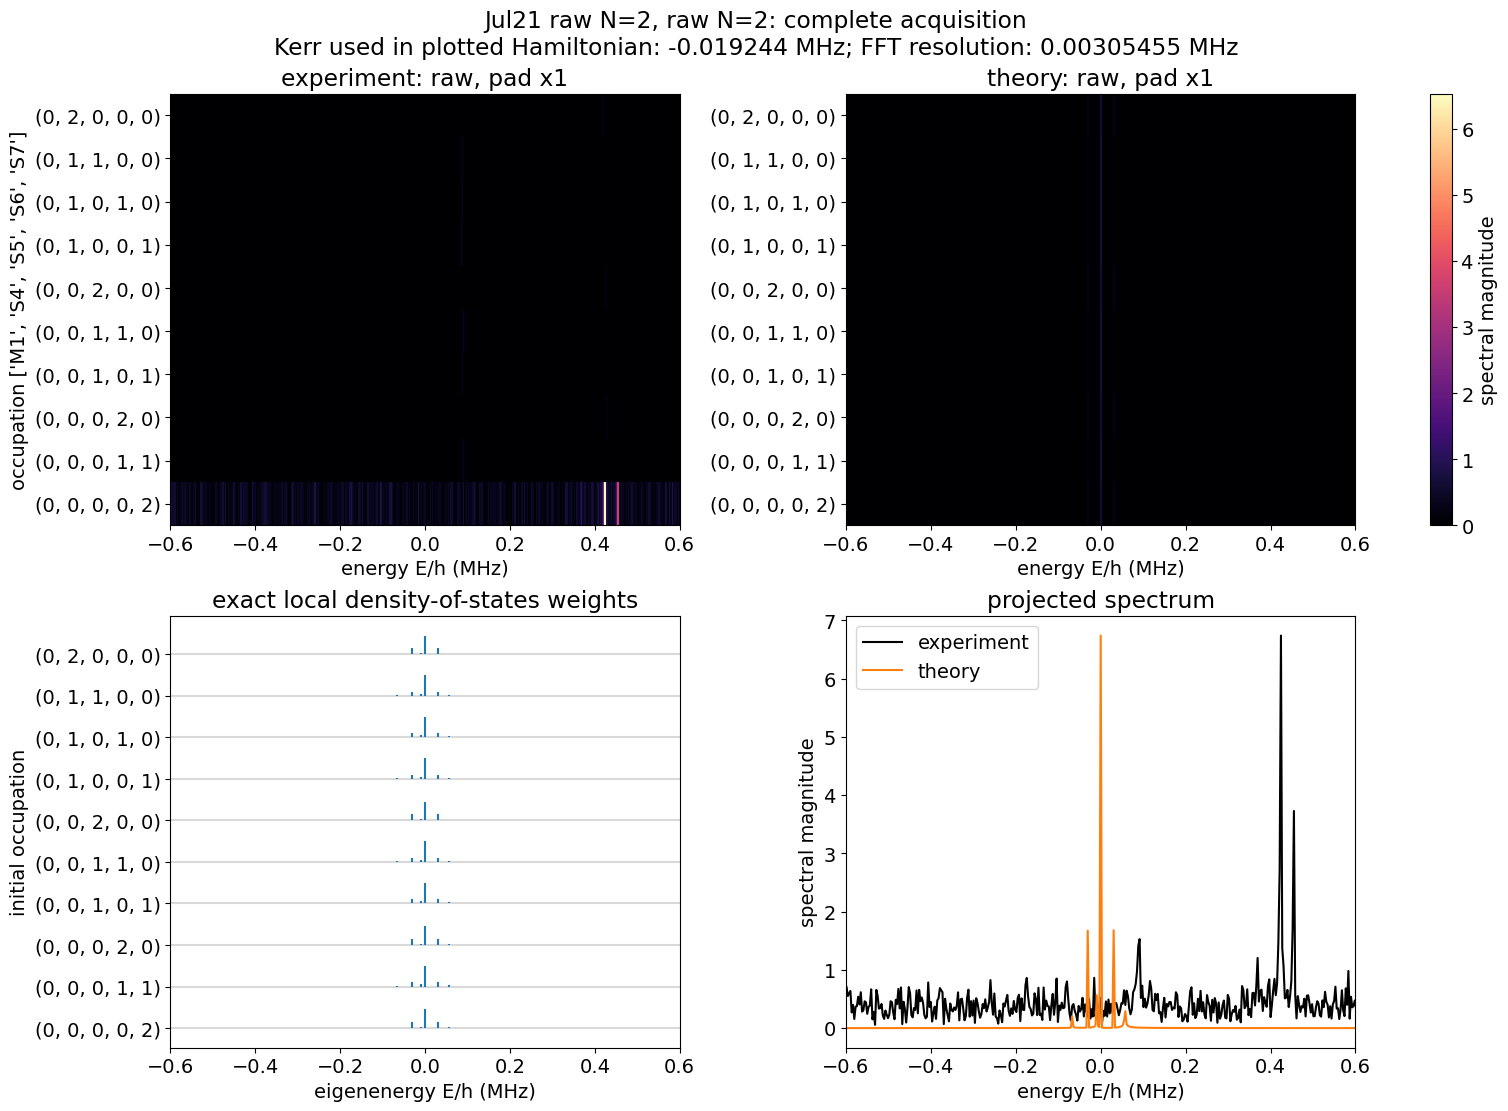

In [32]:
# Jul21 raw N=2 / raw N=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul21 raw N=2'
h5_group = 'raw N=2'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = []
h5_spectroscopy_job_ids = [
    'JOB-20260721-00267', 'JOB-20260721-00271', 'JOB-20260721-00269', 'JOB-20260721-00273',
    'JOB-20260721-00275', 'JOB-20260721-00279', 'JOB-20260721-00277', 'JOB-20260721-00281',
    'JOB-20260721-00283', 'JOB-20260721-00287', 'JOB-20260721-00285', 'JOB-20260721-00289',
    'JOB-20260721-00291', 'JOB-20260721-00295', 'JOB-20260721-00293', 'JOB-20260721-00297',
    'JOB-20260721-00299', 'JOB-20260721-00303', 'JOB-20260721-00301', 'JOB-20260721-00305',
    'JOB-20260721-00307', 'JOB-20260721-00311', 'JOB-20260721-00309', 'JOB-20260721-00313',
    'JOB-20260721-00315', 'JOB-20260721-00319', 'JOB-20260721-00317', 'JOB-20260721-00321',
    'JOB-20260721-00323', 'JOB-20260721-00327', 'JOB-20260721-00325', 'JOB-20260721-00329',
    'JOB-20260721-00331', 'JOB-20260721-00335', 'JOB-20260721-00333', 'JOB-20260721-00337',
    'JOB-20260721-00339', 'JOB-20260721-00343', 'JOB-20260721-00341', 'JOB-20260721-00345',
]
h5_floquet_version = "CFG-FL-20260717-00028"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = True
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Jul22 N=1


### Jul22 N=1 / N=1


  station config: CFG-FL-20260717-00028 (local CSV + RFSoC clock snapshot)

Jul22 N=1: locating 19 spectroscopy HDF5 jobs
  spectroscopy headers: 10/19 in 0.0s


  calibration: loaded 10 HDF5 jobs
  spectroscopy arrays: 10 in 0.0s
  spectroscopy: loaded 10 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260717-00028 + HDF5 config + RFSoC clock


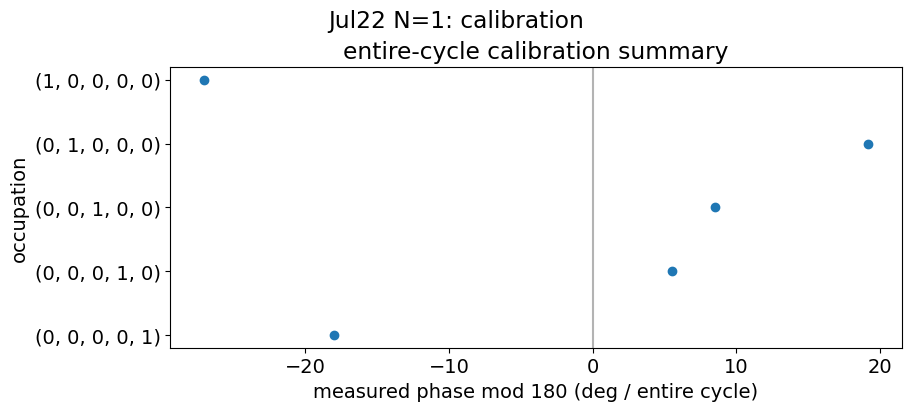

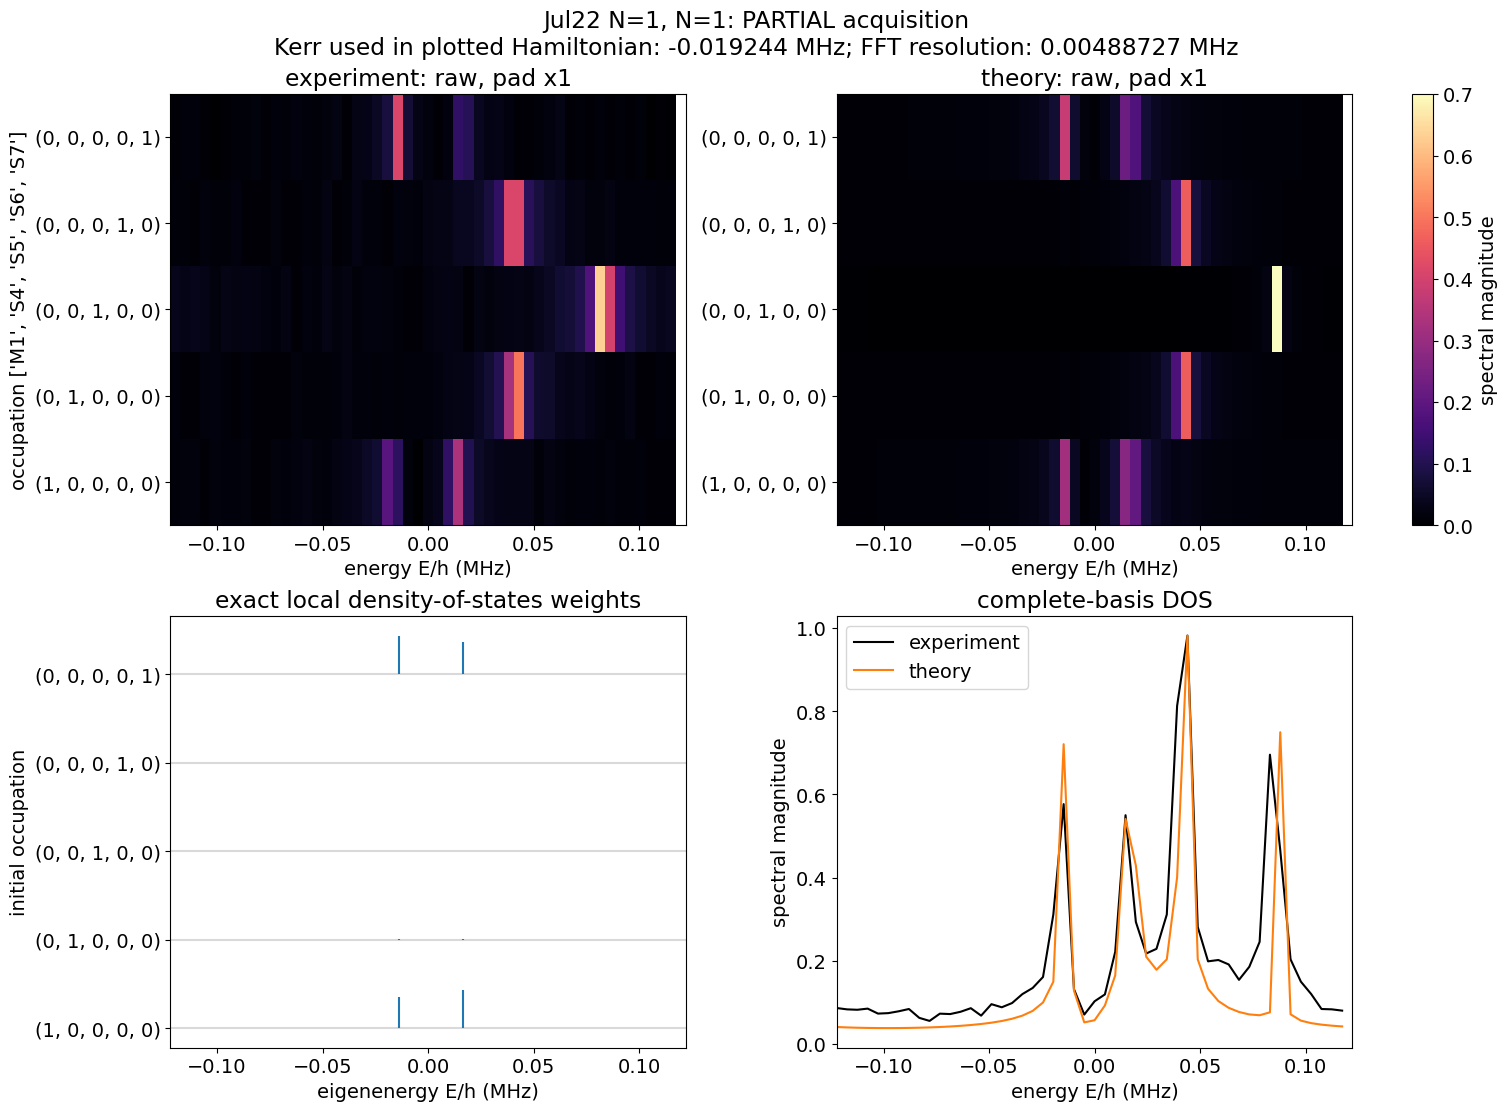

In [ ]:
# Jul22 N=1 / N=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=1'
h5_group = 'N=1'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260722, 557, 566)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 577, 595)
h5_floquet_version = "CFG-FL-20260717-00028"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)


if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Jul22 N=2


### Jul22 N=2 / N=2


  station config: CFG-FL-20260722-00001 (local CSV + RFSoC clock snapshot)

Jul22 N=2: locating 30 spectroscopy HDF5 jobs


  spectroscopy headers: 28/30 in 0.0s
  HDF5 files were found but their headers were rejected: JOB-20260722-00035_QsimBaseExperiment.h5: unrelated HDF5 experiment
  calibration: no matching paired HDF5 jobs
  spectroscopy arrays: 28 in 0.2s
  spectroscopy: loaded 28 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260722-00001 + HDF5 config + RFSoC clock


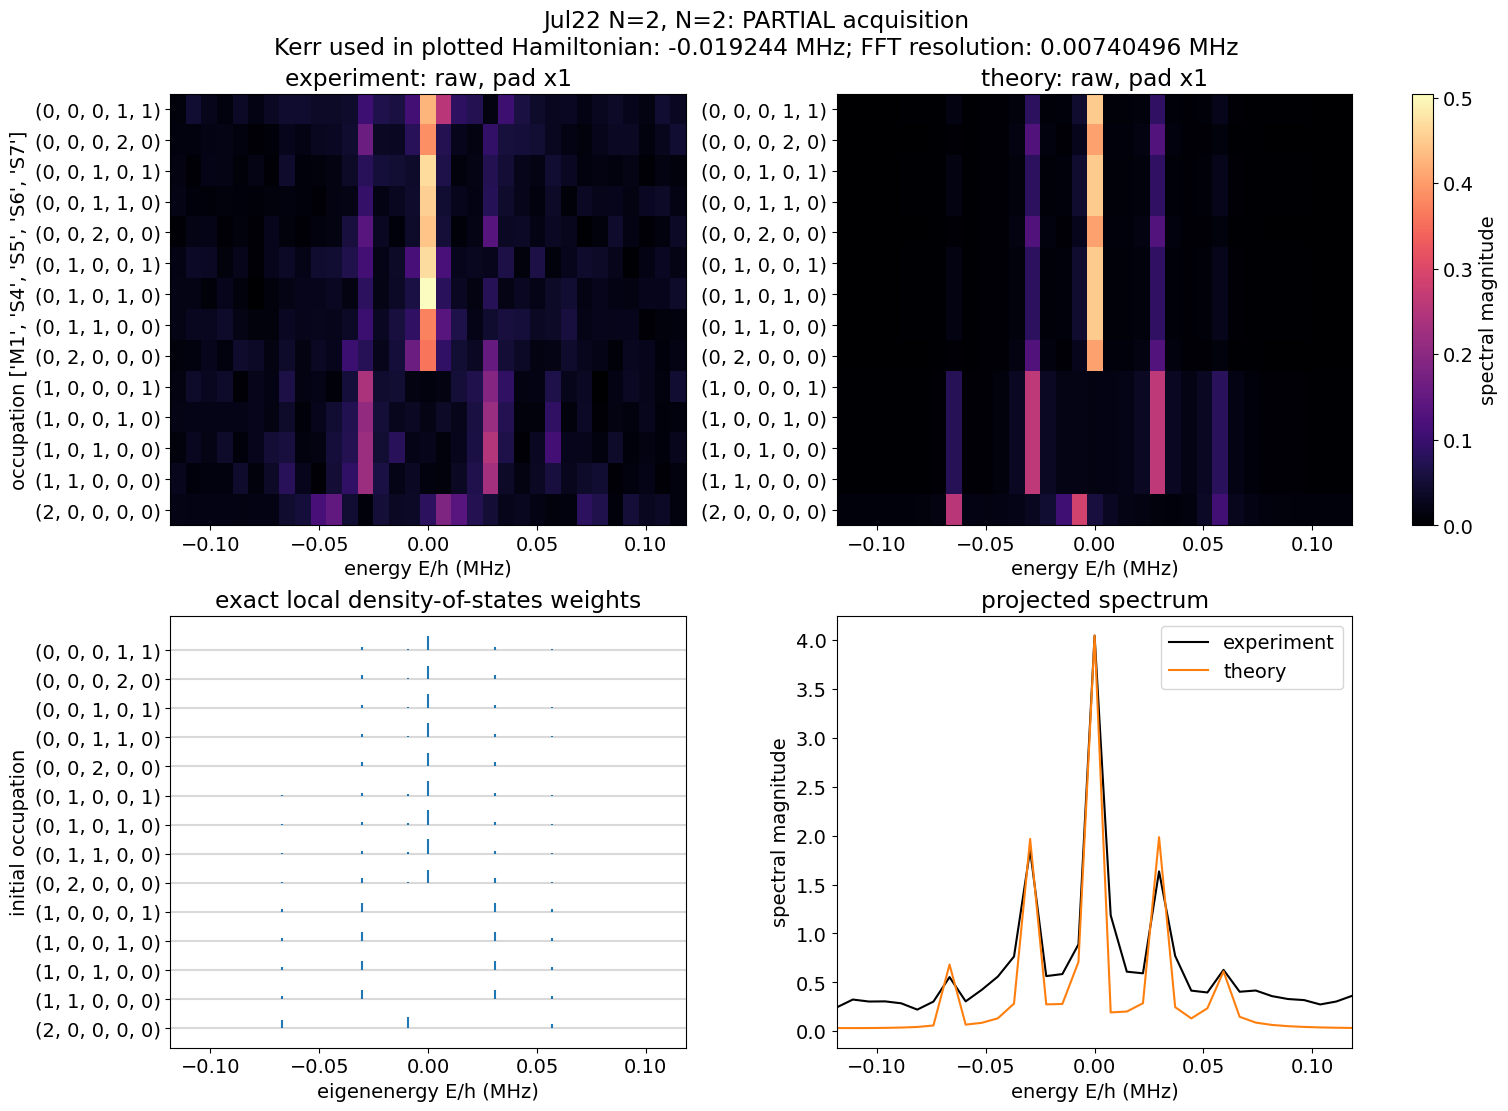

In [36]:
# Jul22 N=2 / N=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=2'
h5_group = 'N=2'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260722, 35, 64)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 215, 244)
h5_floquet_version = 'CFG-FL-20260722-00001'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Jul22 N=2 supplement


### Jul22 N=2 supplement / N=2 supplement


  station config: CFG-FL-20260722-00001 (local CSV + RFSoC clock snapshot)

Jul22 N=2 supplement: locating 3 spectroscopy HDF5 jobs


  spectroscopy headers: 2/3 in 0.0s
  HDF5 files were found but their headers were rejected: JOB-20260722-00425_QsimBaseExperiment.h5: unrelated HDF5 experiment
  calibration: no matching paired HDF5 jobs
  spectroscopy arrays: 2 in 0.0s
  spectroscopy: loaded 2 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260722-00001 + HDF5 config + RFSoC clock


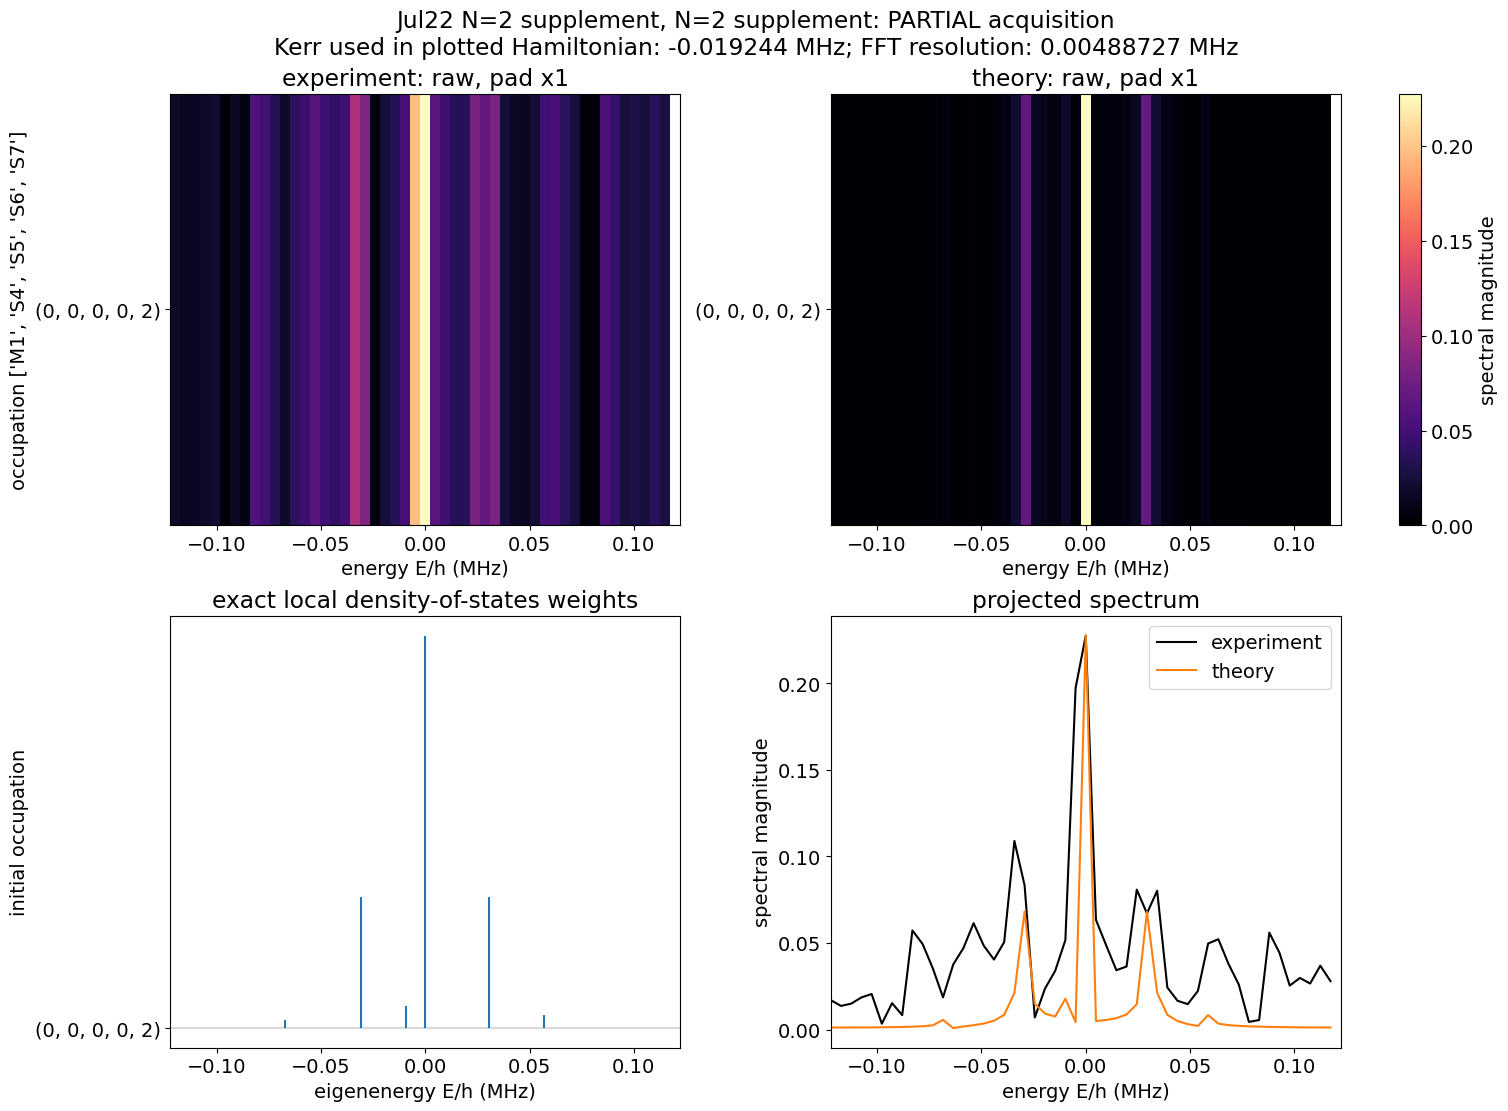

In [38]:
# Jul22 N=2 supplement / N=2 supplement: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=2 supplement'
h5_group = 'N=2 supplement'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260722, 425, 426)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 452, 454)
h5_floquet_version = 'CFG-FL-20260722-00001'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Jul23 N=3


### Jul23 N=3 / N=3


  station config: CFG-FL-20260722-00001 (local CSV + RFSoC clock snapshot)

Jul23 N=3: locating 101 spectroscopy HDF5 jobs
  spectroscopy headers: 70/101 in 0.1s
  HDF5 files were found but their headers were rejected: JOB-20260722-00683_QsimBaseExperiment.h5: unrelated HDF5 experiment
  calibration: no matching paired HDF5 jobs
  spectroscopy arrays: 70 in 0.4s
  spectroscopy: loaded 70 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260722-00001 + HDF5 config + RFSoC clock


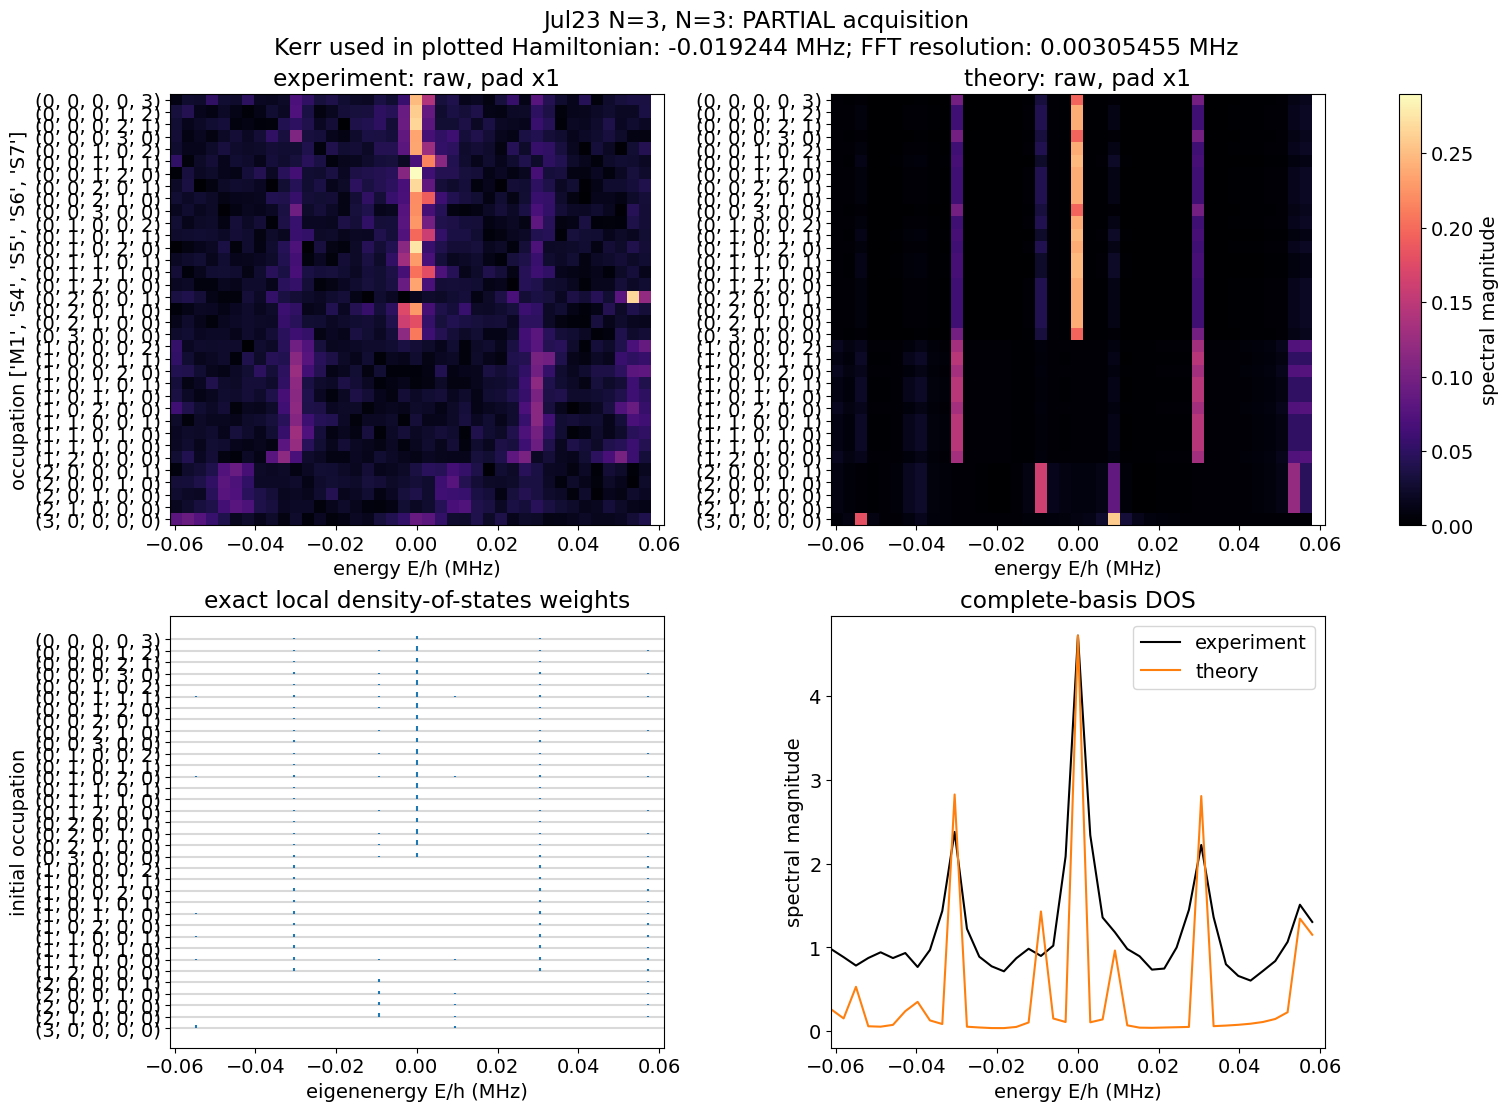

In [39]:
# Jul23 N=3 / N=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul23 N=3'
h5_group = 'N=3'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = (
    h5_job_ids(20260722, 683, 712)
    + h5_job_ids(20260723, 1, 40)
)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260723, 48, 85)
    + h5_job_ids(20260723, 87, 149)
)
h5_floquet_version = 'CFG-FL-20260722-00001'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Jul22 N=4


### Jul22 N=4 / N=4


  station config: CFG-FL-20260717-00028 (local CSV + RFSoC clock snapshot)

Jul22 N=4: locating 10 spectroscopy HDF5 jobs


  spectroscopy headers: 10/10 in 0.0s
  HDF5 files were found but their headers were rejected: JOB-20260721-00423_QsimBaseExperiment.h5: unrelated HDF5 experiment
  calibration: no matching paired HDF5 jobs
  spectroscopy arrays: 10 in 0.1s
  spectroscopy: loaded 10 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260717-00028 + HDF5 config + RFSoC clock


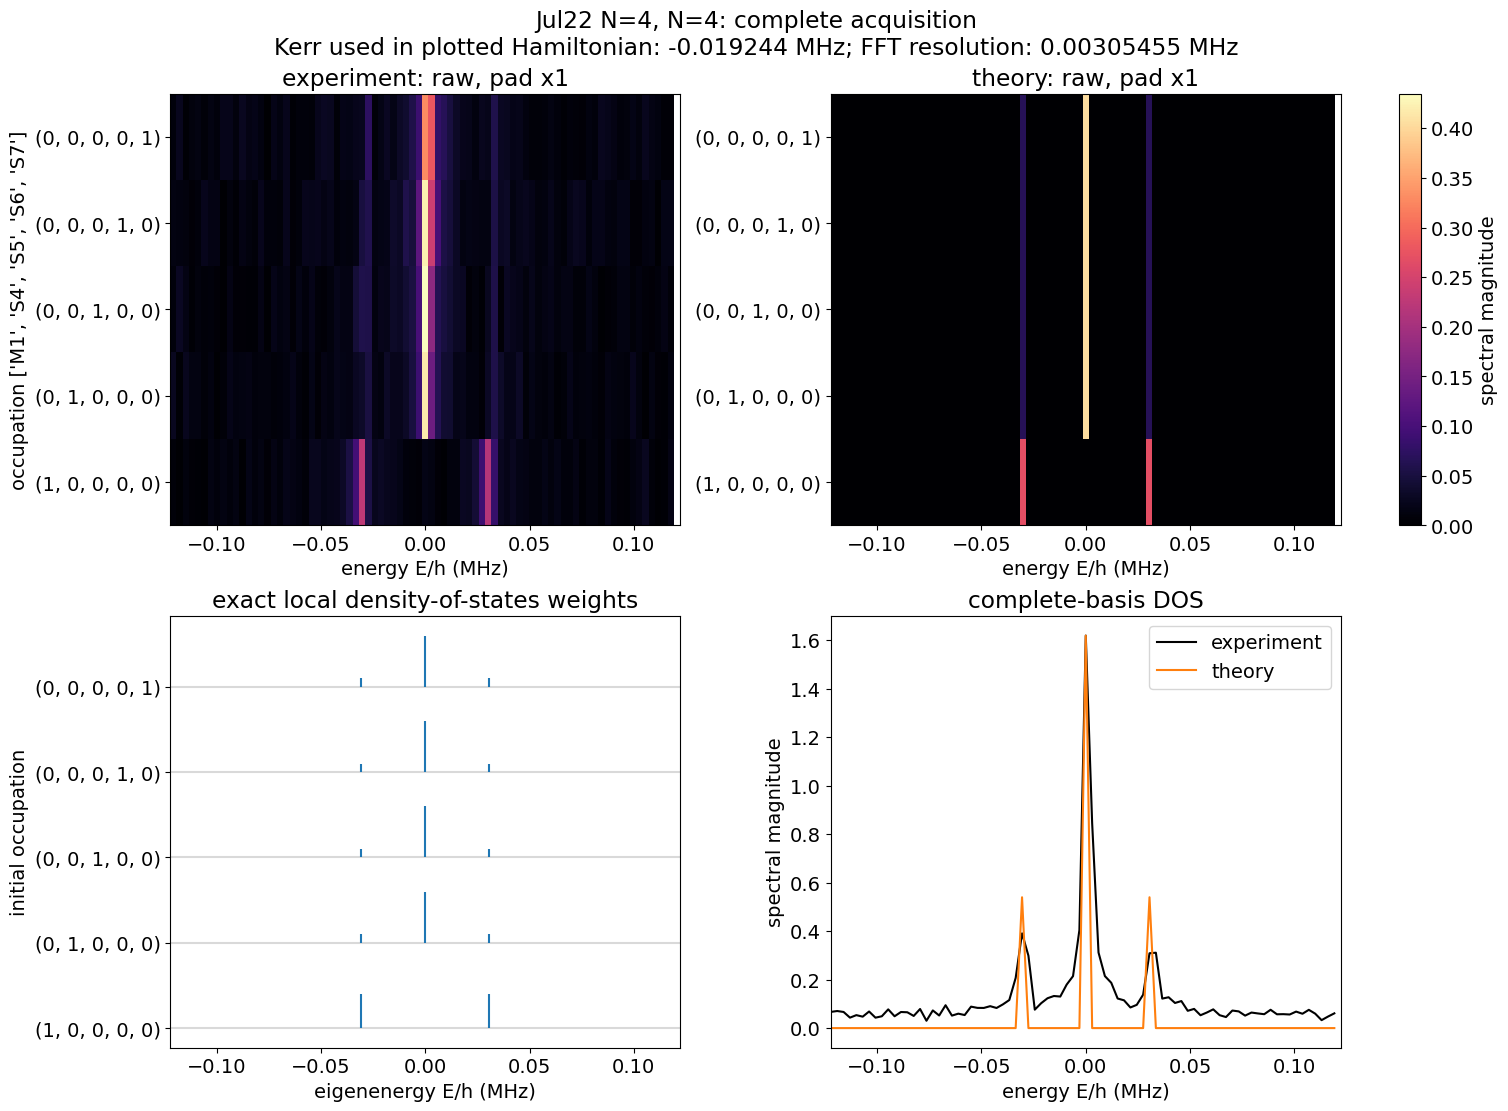

In [42]:
# Jul22 N=4 / N=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=4'
h5_group = 'N=4'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260721, 423, 432)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 5, 14)
h5_floquet_version = "CFG-FL-20260717-00028"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Aug15 four-realization


### Aug15 four-realization / four-realization


  station config: CFG-FL-20260814-00076 (local CSV + RFSoC clock snapshot)

Aug15 four-realization: locating 8 spectroscopy HDF5 jobs
  spectroscopy headers: 8/8 in 0.0s
  spectroscopy arrays: 8 in 0.1s
  spectroscopy: loaded 8 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260814-00076 + HDF5 config + RFSoC clock


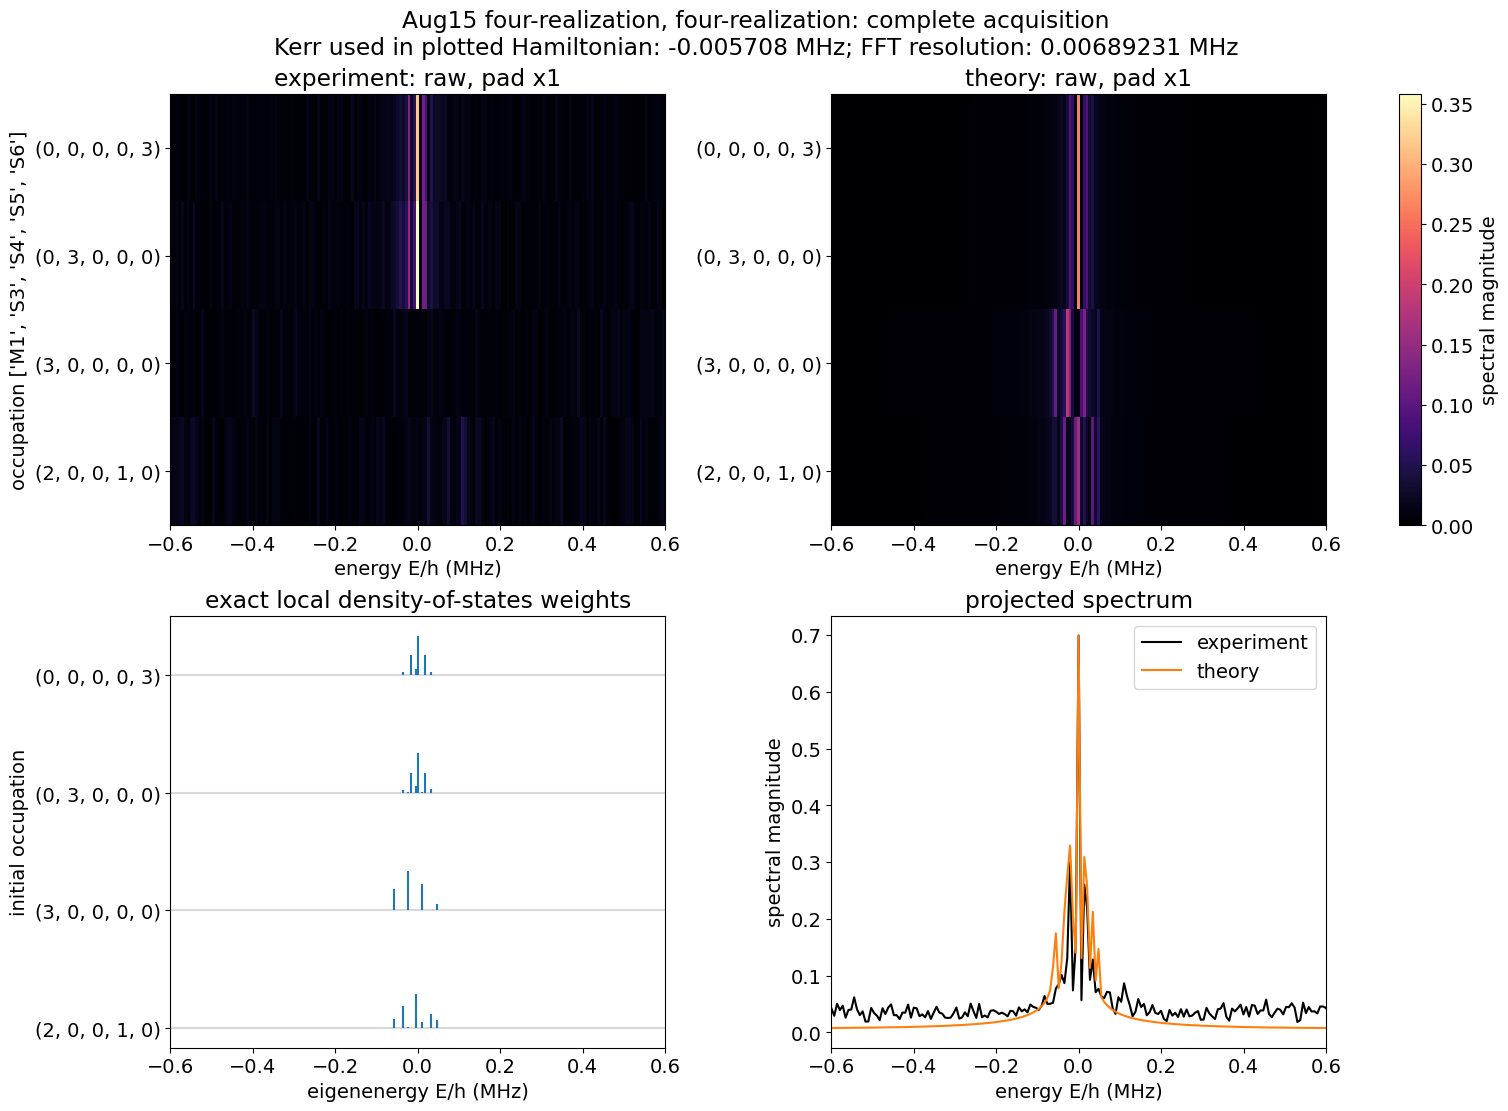

In [43]:
# Aug15 four-realization / four-realization: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15 four-realization'
h5_group = 'four-realization'
h5_project = '260814_qsim_encspec'
h5_calibration_job_ids = []
h5_spectroscopy_job_ids = h5_job_ids(20260815, 9, 16)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Aug15-17 N=3 and disorder


### Aug15-17 N=3 and disorder / N=3


  station config: CFG-FL-20260814-00076 (local CSV + RFSoC clock snapshot)

Aug15-17 N=3 and disorder: locating 70 spectroscopy HDF5 jobs


  spectroscopy headers: 70/70 in 0.1s
  HDF5 files were found but their headers were rejected: JOB-20260815-00113_EncodingHamiltonianSpectroscopyExperiment.h5: unrelated HDF5 experiment
  calibration: no matching paired HDF5 jobs
  spectroscopy arrays: 70 in 0.6s
  spectroscopy: loaded 70 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260814-00076 + HDF5 config + RFSoC clock


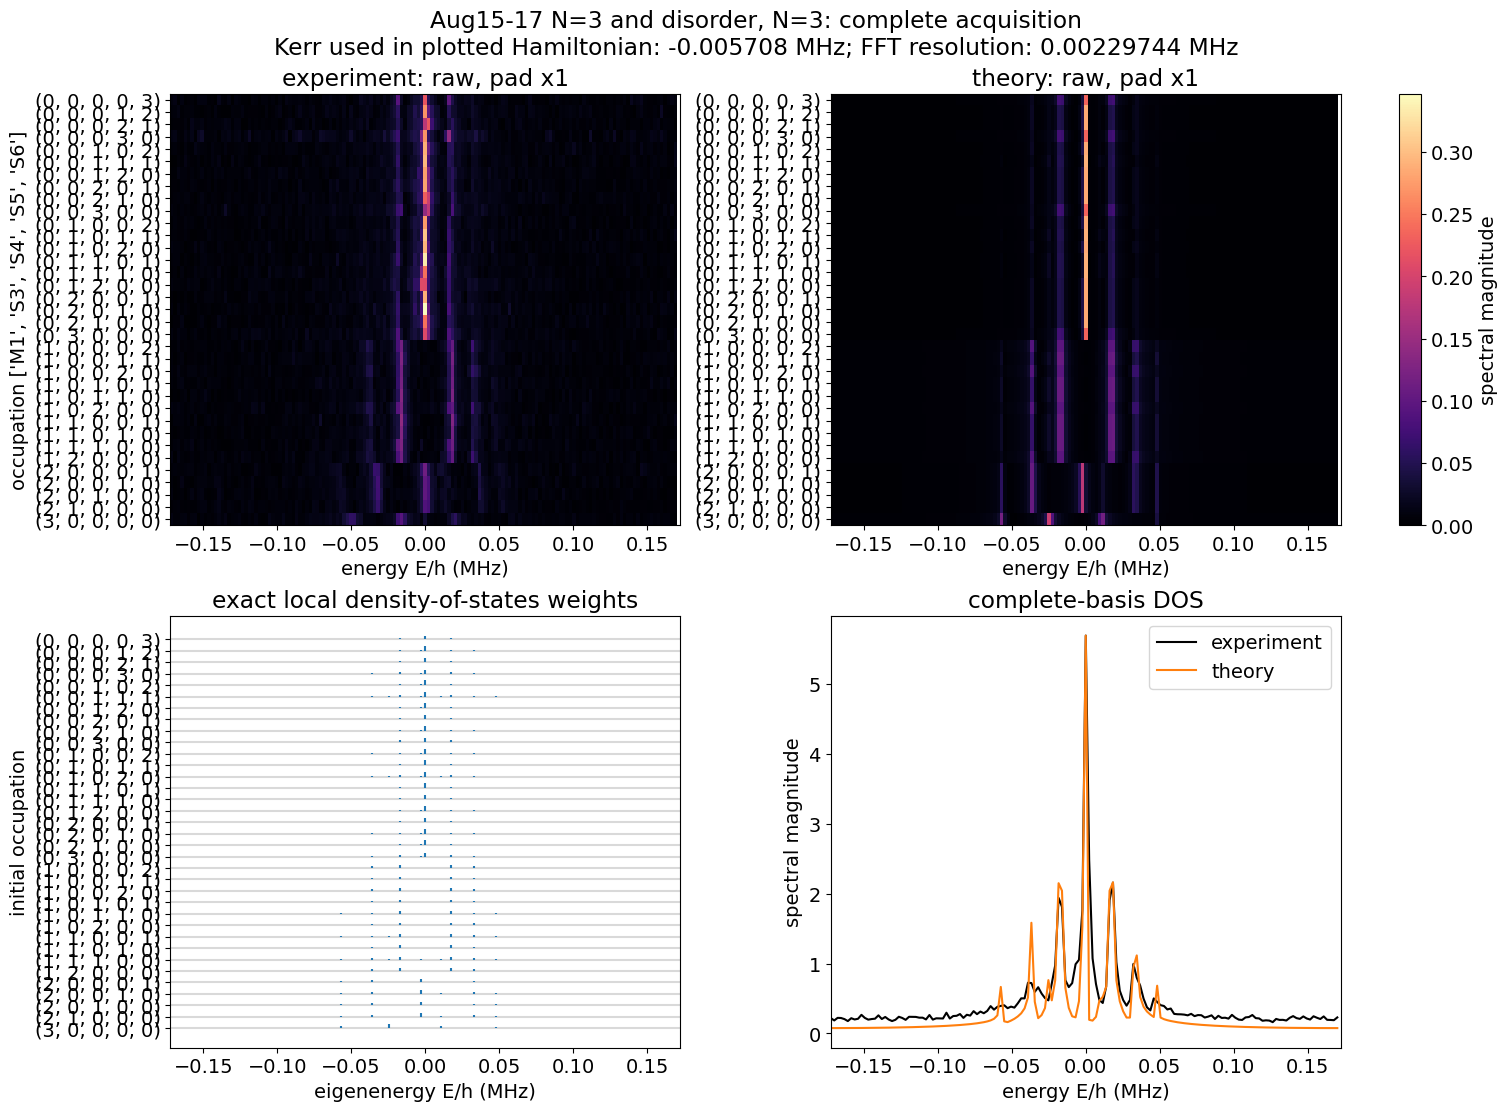

In [47]:
# Aug15-17 N=3 and disorder / N=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'N=3'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260815, 183, 242)
    + h5_job_ids(20260816, 1, 10)
)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug15-17 N=3 and disorder / r=0


In [68]:
h5_calibration_expt.cfg.expt.keys()

AttributeError: 'NoneType' object has no attribute 'cfg'

  station config: CFG-FL-20260814-00076 (local CSV + RFSoC clock snapshot)

Aug15-17 N=3 and disorder: locating 20 spectroscopy HDF5 jobs
  spectroscopy headers: 20/20 in 0.0s
  HDF5 files were found but their headers were rejected: JOB-20260815-00113_EncodingHamiltonianSpectroscopyExperiment.h5: unrelated HDF5 experiment
  calibration: no matching paired HDF5 jobs
  spectroscopy arrays: 20 in 0.1s
  spectroscopy: loaded 20 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260814-00076 + HDF5 config + RFSoC clock


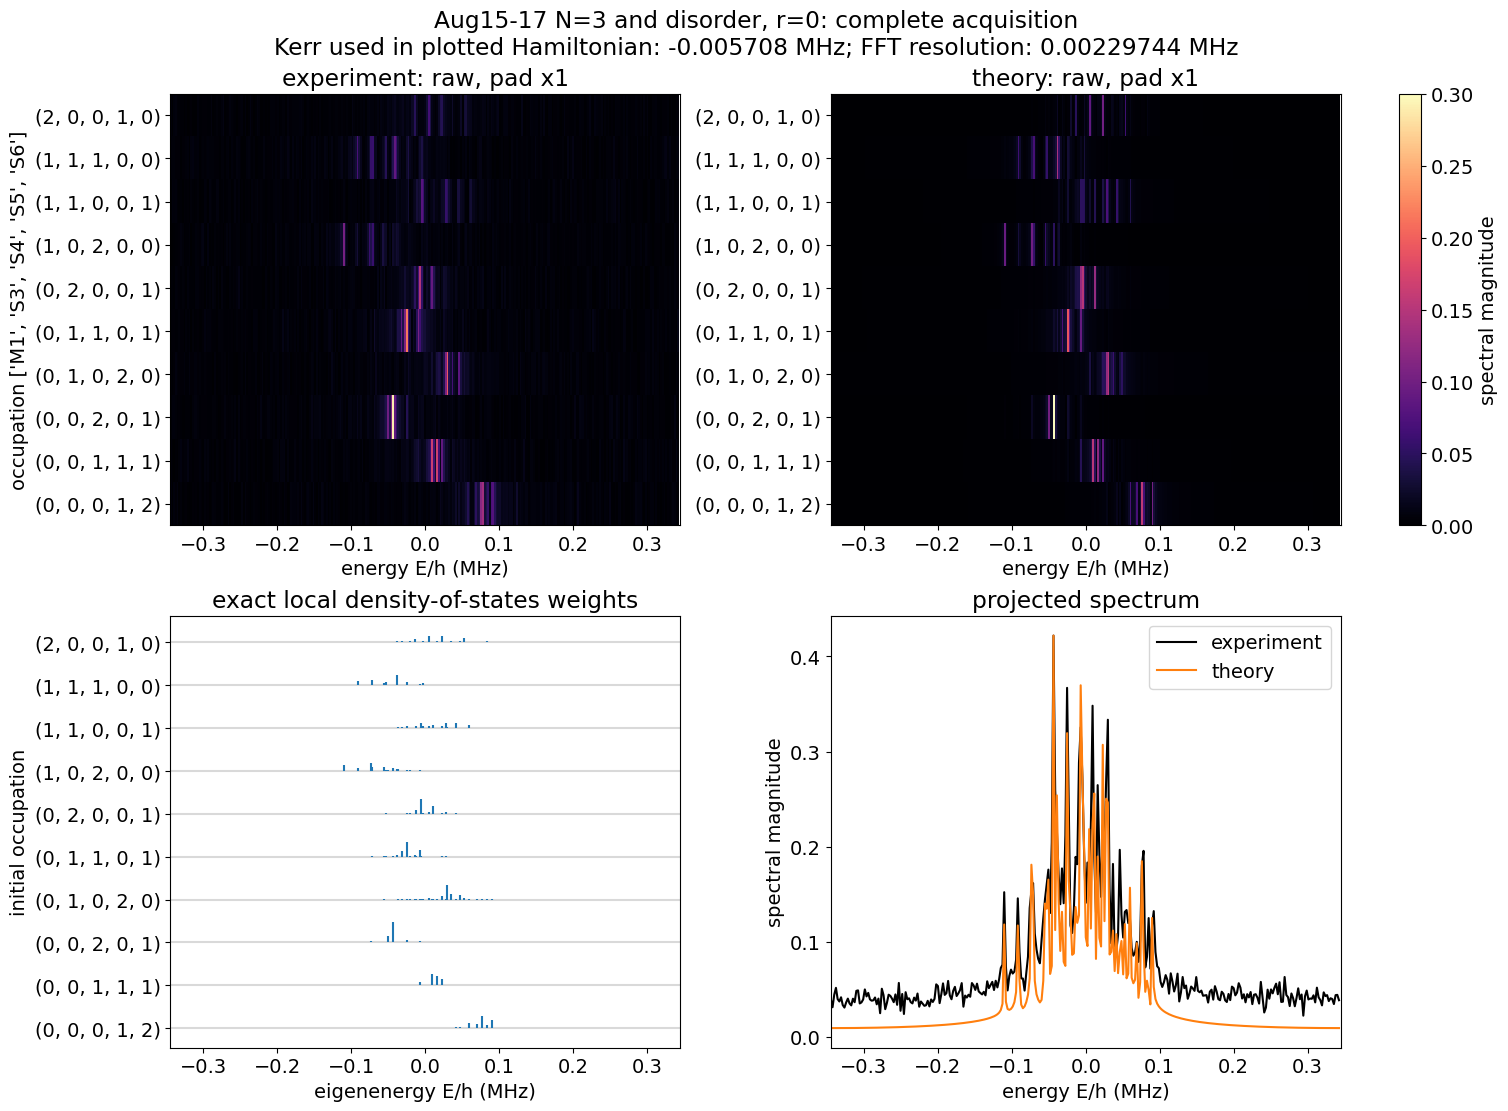

In [67]:
# Aug15-17 N=3 and disorder / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'r=0'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = h5_job_ids(20260816, 13, 32)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug15-17 N=3 and disorder / r=1


In [ ]:
# Aug15-17 N=3 and disorder / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'r=1'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = h5_job_ids(20260816, 33, 52)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug15-17 N=3 and disorder / r=2


In [ ]:
# Aug15-17 N=3 and disorder / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'r=2'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = h5_job_ids(20260816, 53, 72)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug15-17 N=3 and disorder / r=3


In [ ]:
# Aug15-17 N=3 and disorder / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'r=3'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = h5_job_ids(20260817, 1, 20)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Aug26 four-realization


### Aug26 four-realization / four-realization


In [ ]:
# Aug26 four-realization / four-realization: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug26 four-realization'
h5_group = 'four-realization'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = []
h5_spectroscopy_job_ids = h5_job_ids(20260826, 67, 78)
# Lab note 8/20/2026: this exact JOB list follows the post-calibration config snapshot.
h5_floquet_version = 'CFG-FL-20260825-00094'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Aug28-30 diagonal disorder


### Aug28-30 diagonal disorder / r=0


In [ ]:
# Aug28-30 diagonal disorder / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 16, 35)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=1


In [ ]:
# Aug28-30 diagonal disorder / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 36, 55)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=2


In [ ]:
# Aug28-30 diagonal disorder / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 56, 75)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=3


In [ ]:
# Aug28-30 diagonal disorder / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 76, 95)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=4


In [ ]:
# Aug28-30 diagonal disorder / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 96, 115)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=5


In [ ]:
# Aug28-30 diagonal disorder / r=5: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=5'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 116, 135)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=6


In [ ]:
# Aug28-30 diagonal disorder / r=6: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=6'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 136, 155)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=7


In [ ]:
# Aug28-30 diagonal disorder / r=7: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=7'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 156, 175)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=8


In [ ]:
# Aug28-30 diagonal disorder / r=8: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=8'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 176, 195)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=9


In [ ]:
# Aug28-30 diagonal disorder / r=9: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=9'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 196, 215)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=10


In [ ]:
# Aug28-30 diagonal disorder / r=10: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=10'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 216, 235)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=11


In [ ]:
# Aug28-30 diagonal disorder / r=11: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=11'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 236, 255)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=12


In [ ]:
# Aug28-30 diagonal disorder / r=12: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=12'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260829, 256, 271)
    + h5_job_ids(20260830, 1, 4)
)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=13


In [ ]:
# Aug28-30 diagonal disorder / r=13: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=13'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 5, 24)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=14


In [ ]:
# Aug28-30 diagonal disorder / r=14: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=14'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 25, 44)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=15


In [ ]:
# Aug28-30 diagonal disorder / r=15: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=15'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 45, 64)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=16


In [ ]:
# Aug28-30 diagonal disorder / r=16: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=16'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 65, 84)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=17


In [ ]:
# Aug28-30 diagonal disorder / r=17: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=17'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 85, 104)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=18


In [ ]:
# Aug28-30 diagonal disorder / r=18: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=18'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 105, 124)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=19


In [ ]:
# Aug28-30 diagonal disorder / r=19: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=19'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 125, 135)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep10 K3.6 g29.2


### Sep10 K3.6 g29.2 / r=0


In [ ]:
# Sep10 K3.6 g29.2 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260910, 31, 72)
    + h5_job_ids(20260911, 46, 87)
)
# Lab note ties Sep10 JOB-00031..00072 to CFG-FL-20260909-00042.
# The Sep11 JOBs in this same cell have no verified Floquet version.
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=1


In [ ]:
# Sep10 K3.6 g29.2 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260912, 33, 136)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=2


In [ ]:
# Sep10 K3.6 g29.2 / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260912, 137, 241)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=3


In [ ]:
# Sep10 K3.6 g29.2 / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260912, 243, 347)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=4


In [ ]:
# Sep10 K3.6 g29.2 / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260912, 348, 419)
    + h5_job_ids(20260913, 1, 64)
)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=5


In [ ]:
# Sep10 K3.6 g29.2 / r=5: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=5'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260913, 65, 168)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=6


In [ ]:
# Sep10 K3.6 g29.2 / r=6: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=6'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260913, 169, 273)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=7


In [ ]:
# Sep10 K3.6 g29.2 / r=7: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=7'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260913, 274, 378)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=8


In [ ]:
# Sep10 K3.6 g29.2 / r=8: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=8'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260913, 380, 399)
    + h5_job_ids(20260914, 1, 84)
)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep07 K52.3 g29.2


### Sep07 K52.3 g29.2 / r=0


In [ ]:
# Sep07 K52.3 g29.2 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = h5_job_ids(20260907, 304, 333)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep07 K52.3 g29.2 / r=1


In [ ]:
# Sep07 K52.3 g29.2 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = h5_job_ids(20260907, 334, 363)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep07 K52.3 g29.2 / r=2


In [ ]:
# Sep07 K52.3 g29.2 / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = h5_job_ids(20260907, 364, 393)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep07 K52.3 g29.2 / r=3


In [ ]:
# Sep07 K52.3 g29.2 / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260907, 406, 415)
    + h5_job_ids(20260908, 1, 20)
)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep07 K52.3 g29.2 / r=4


In [ ]:
# Sep07 K52.3 g29.2 / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = h5_job_ids(20260908, 21, 50)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep07 K52.3 g29.2 / r=5


In [ ]:
# Sep07 K52.3 g29.2 / r=5: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=5'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = h5_job_ids(20260908, 51, 80)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep05 K3.6 g30


### Sep05 K3.6 g30 / r=0


In [ ]:
# Sep05 K3.6 g30 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep05 K3.6 g30'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260905, 75, 144)
h5_spectroscopy_job_ids = h5_job_ids(20260905, 145, 159)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260905-00045'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep05 K3.6 g30 / r=1


In [ ]:
# Sep05 K3.6 g30 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep05 K3.6 g30'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260905, 75, 144)
h5_spectroscopy_job_ids = h5_job_ids(20260905, 160, 174)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260905-00045'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep01 K44 g15


### Sep01 K44 g15 / r=0


In [ ]:
# Sep01 K44 g15 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep01 K44 g15'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids = h5_job_ids(20260901, 3, 12)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep01 K44 g15 / r=1


In [ ]:
# Sep01 K44 g15 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep01 K44 g15'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids = h5_job_ids(20260901, 13, 22)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep01 K44 g15 / r=2


In [ ]:
# Sep01 K44 g15 / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep01 K44 g15'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids = h5_job_ids(20260901, 23, 32)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep01 K44 g15 / r=3


In [ ]:
# Sep01 K44 g15 / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep01 K44 g15'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids = h5_job_ids(20260901, 33, 42)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep01 K44 g15 / r=4


In [ ]:
# Sep01 K44 g15 / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep01 K44 g15'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids = h5_job_ids(20260901, 43, 52)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep02 K20 g15


### Sep02 K20 g15 / r=0


In [ ]:
# Sep02 K20 g15 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02 K20 g15'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids = h5_job_ids(20260902, 71, 80)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00093'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02 K20 g15 / r=1


In [ ]:
# Sep02 K20 g15 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02 K20 g15'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids = h5_job_ids(20260902, 81, 90)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00093'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02 K20 g15 / r=2


In [ ]:
# Sep02 K20 g15 / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02 K20 g15'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260902, 91, 94)
    + [
        'JOB-20260902-00096', 'JOB-20260902-00097', 'JOB-20260902-00099', 'JOB-20260902-00100',
        'JOB-20260902-00102', 'JOB-20260902-00103',
    ]
)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00093'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02 K20 g15 / r=3


In [ ]:
# Sep02 K20 g15 / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02 K20 g15'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids = [
    'JOB-20260902-00105', 'JOB-20260902-00106', 'JOB-20260902-00108', 'JOB-20260902-00109',
    'JOB-20260902-00111', 'JOB-20260902-00112', 'JOB-20260902-00114', 'JOB-20260902-00115',
    'JOB-20260902-00117', 'JOB-20260902-00118',
]
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00093'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02 K20 g15 / r=4


In [ ]:
# Sep02 K20 g15 / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02 K20 g15'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids = [
    'JOB-20260902-00120', 'JOB-20260902-00121', 'JOB-20260902-00123', 'JOB-20260902-00124',
    'JOB-20260902-00126', 'JOB-20260902-00127', 'JOB-20260902-00129', 'JOB-20260902-00130',
    'JOB-20260902-00132', 'JOB-20260902-00133',
]
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00093'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep02-04 K3.6 g15


### Sep02-04 K3.6 g15 / r=0


In [ ]:
# Sep02-04 K3.6 g15 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = (
    ['JOB-20260902-00840', 'JOB-20260902-00841']
    + h5_job_ids(20260903, 1, 13)
)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=1


In [ ]:
# Sep02-04 K3.6 g15 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 14, 28)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=2


In [ ]:
# Sep02-04 K3.6 g15 / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 29, 43)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=3


In [ ]:
# Sep02-04 K3.6 g15 / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 44, 58)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=4


In [ ]:
# Sep02-04 K3.6 g15 / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = [
    'JOB-20260903-00059', 'JOB-20260903-00060', 'JOB-20260903-00062', 'JOB-20260903-00063',
    'JOB-20260903-00065', 'JOB-20260903-00066', 'JOB-20260903-00068', 'JOB-20260903-00069',
    'JOB-20260903-00071', 'JOB-20260903-00072', 'JOB-20260903-00074', 'JOB-20260903-00075',
    'JOB-20260903-00077', 'JOB-20260903-00078', 'JOB-20260903-00080',
]
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=5


In [ ]:
# Sep02-04 K3.6 g15 / r=5: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=5'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = [
    'JOB-20260903-00082', 'JOB-20260903-00083', 'JOB-20260903-00085', 'JOB-20260903-00086',
    'JOB-20260903-00088', 'JOB-20260903-00089', 'JOB-20260903-00091', 'JOB-20260903-00092',
    'JOB-20260903-00094', 'JOB-20260903-00095', 'JOB-20260903-00097', 'JOB-20260903-00098',
    'JOB-20260903-00100', 'JOB-20260903-00101', 'JOB-20260903-00103',
]
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=6


In [ ]:
# Sep02-04 K3.6 g15 / r=6: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=6'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = [
    'JOB-20260903-00105', 'JOB-20260903-00106', 'JOB-20260903-00108', 'JOB-20260903-00109',
    'JOB-20260903-00111', 'JOB-20260903-00112', 'JOB-20260903-00114', 'JOB-20260903-00115',
    'JOB-20260903-00117', 'JOB-20260903-00118', 'JOB-20260903-00120', 'JOB-20260903-00121',
    'JOB-20260903-00123', 'JOB-20260903-00124', 'JOB-20260903-00126',
]
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=7


In [ ]:
# Sep02-04 K3.6 g15 / r=7: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=7'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = (
    [
        'JOB-20260903-00128', 'JOB-20260903-00129', 'JOB-20260903-00131', 'JOB-20260903-00132',
        'JOB-20260903-00134', 'JOB-20260903-00135', 'JOB-20260903-00137', 'JOB-20260903-00138',
        'JOB-20260903-00140', 'JOB-20260903-00141', 'JOB-20260903-00143', 'JOB-20260903-00144',
    ]
    + h5_job_ids(20260903, 146, 148)
)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=8


In [ ]:
# Sep02-04 K3.6 g15 / r=8: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=8'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 149, 163)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=9


In [ ]:
# Sep02-04 K3.6 g15 / r=9: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=9'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 164, 178)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=10


In [ ]:
# Sep02-04 K3.6 g15 / r=10: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=10'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 179, 193)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=11


In [ ]:
# Sep02-04 K3.6 g15 / r=11: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=11'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260903, 194, 203)
    + h5_job_ids(20260904, 1, 5)
)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=12


In [ ]:
# Sep02-04 K3.6 g15 / r=12: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=12'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 6, 20)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=13


In [ ]:
# Sep02-04 K3.6 g15 / r=13: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=13'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 21, 35)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=14


In [ ]:
# Sep02-04 K3.6 g15 / r=14: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=14'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 36, 50)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=15


In [ ]:
# Sep02-04 K3.6 g15 / r=15: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=15'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 51, 65)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=16


In [ ]:
# Sep02-04 K3.6 g15 / r=16: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=16'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 66, 80)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=17


In [ ]:
# Sep02-04 K3.6 g15 / r=17: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=17'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 81, 95)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=18


In [ ]:
# Sep02-04 K3.6 g15 / r=18: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=18'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 96, 110)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)
